# Gene Regulatory Network Analysis with SCENIC

### What is SCENIC?

**SCENIC** (Single-Cell rEgulatory Network Inference and Clustering) is a classic method for reconstructing **gene regulatory networks** (GRNs) from single-cell RNA-seq data. This tutorial uses the enhanced SCENIC workflow in **OmicVerse** to run the full analysis, from data preparation and GRN inference to regulon construction and regulon activity analysis.

SCENIC is designed to do the following at the same time:
- **Infer transcription factor regulatory networks** from single-cell expression data.
- Identify cell states based on regulatory activity.
- Discover cell-type-specific **regulons** (TF + direct target genes).
- Quantify TF regulatory activity at single-cell resolution.

### The SCENIC Workflow

The SCENIC workflow usually contains three major steps:

#### 1. Gene Regulatory Network (GRN) Inference
- **Traditional methods**: GRNBoost2 or GENIE3 identify candidate TF-target relationships.
- **OmicVerse method**: RegDiffusion provides faster GRN inference.
- **Input**: Single-cell expression matrix.
- **Output**: TF-target adjacency table with importance scores.

#### 2. Regulon Inference (Pruning)
- **Method**: cisTarget is used for TF motif enrichment analysis.
- **Purpose**: Refine co-expression modules into direct target-gene sets with motif support.
- **Process**: Search TF-binding motifs in regulatory regions of target genes.
- **Output**: Regulons, each consisting of a TF and its direct target genes.

#### 3. Cell-Level Activity Scoring (AUCell)
- **Method**: Calculate AUC based on gene rankings within each cell.
- **Purpose**: Quantify regulon activity in each cell.
- **Output**: A cell-by-regulon activity matrix.

**Key OmicVerse Improvements**

1. **Speed optimization**: RegDiffusion accelerates GRN inference, reducing analyses that may otherwise take tens of minutes to hours to a tutorial-friendly runtime.
2. **Dependency management**: OmicVerse reduces common installation and runtime conflicts between `pySCENIC` and `RegDiffusion`.
3. **Workflow encapsulation**: `ov.single.SCENIC` can automatically prepare species-matched cisTarget databases, while still allowing users to pass custom database paths when needed.

**Citation**

If you use this tutorial, please cite:
- **SCENIC**: Van de Sande, B., et al. A scalable SCENIC workflow for single-cell gene regulatory network analysis. *Nat Protoc* 15, 2247-2276 (2020).
- **RegDiffusion**: Zhu H, Slonim D. From Noise to Knowledge: Diffusion Probabilistic Model-Based Neural Inference of Gene Regulatory Networks. *J Comput Biol* 31(11):1087-1103 (2024).

Let's begin.


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Data Preparation

### Loading the Dataset

This tutorial uses the **mouse hematopoiesis dataset** from [Nestorowa et al. (2016, Blood)](https://doi.org/10.1182/blood-2016-05-716480
        
        
        
        
        
        ). The dataset contains single-cell RNA-seq data from mouse hematopoietic stem and progenitor cells, making it well suited for demonstrating regulatory network analysis during cell differentiation.

### Dataset Information

The dataset includes:
- **1,645 cells** from mouse bone marrow
- **3,000 highly variable genes**
- **Multiple cell types**: HSC, MPP, LMPP, GMP, CMP, MEP, and others
- **Pseudotime information** for trajectory-related analysis
- **Precomputed cell type annotations**

> **Note 1**: For your own data, complete standard single-cell preprocessing first and preserve the raw count matrix in `layers['raw_count']` whenever possible. This helps RegDiffusion produce more stable GRN inference results.

> **Note 2**: The official SCENIC tutorial often uses 3000 highly variable genes plus transcription factor genes. This tutorial dataset has already been prepared with 3000 genes for demonstration.


In [2]:
# Load the mouse hematopoiesis dataset
adata = ov.single.mouse_hsc_nestorowa16()

# Display basic information about the dataset
print("Dataset shape:", adata.shape)
print("Cell types available:", adata.obs['cell_type_roughly'].unique())

Load mouse_hsc_nestorowa16_v0.h5ad


  0%|          | 0.00/134M [00:00<?, ?B/s]

Dataset shape: (1645, 3000)
Cell types available: ['MPP', 'HSC', 'LMPP', 'GMP', 'CMP', 'MEP']
Categories (6, object): ['CMP', 'GMP', 'HSC', 'LMPP', 'MEP', 'MPP']


### Required Database Files

SCENIC requires species-matched cisTarget ranking databases and motif-to-TF annotation tables during the regulon pruning step. `ov.single.SCENIC` can now prepare these resources automatically from the `species` argument. In this tutorial, you only need to initialize the object with `species="mm10"`; there is no need to manually write database paths or add a separate file-existence check in the notebook.

#### Mouse mm10 Resources Prepared in This Tutorial

When you run `ov.single.SCENIC(adata=adata, species="mm10")`, OmicVerse caches the following files under `data/scenic/mouse_mm10/`:

1. **Ranking databases** (`.feather` files):
   - `mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather`
   - `mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather`

2. **Motif annotation file** (`.tbl` file):
   - `motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl`

#### Database Roles

- **500 bp upstream + 100 bp downstream**: Covers promoter-proximal regions for proximal regulatory signal analysis.
- **10 kbp upstream + 10 kbp downstream**: Covers wider regulatory regions to capture distal regulatory signals.
- **Motif annotations**: Map motifs to transcription factor gene symbols, supporting the selection of direct target genes from co-expression modules.

#### Optional: Manual Download Sources

If you want to download the resources in advance, the automatic preparation workflow uses the same sources as the links below:

```bash
wget https://resources.aertslab.org/cistarget/databases/mus_musculus/mm10/refseq_r80/mc_v10_clust/gene_based/mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
wget https://resources.aertslab.org/cistarget/databases/mus_musculus/mm10/refseq_r80/mc_v10_clust/gene_based/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
wget https://resources.aertslab.org/cistarget/motif2tf/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl
```

#### Other Species

`species` accepts common aliases:
- **Human**: `"human"` or `"hg38"`
- **Mouse**: `"mouse"` or `"mm10"`
- **Drosophila**: `"fly"` or `"dm6"`

These files are large, so the first run can take some time. Later runs reuse the local cache.


## 2. Initialize the SCENIC Object

### Creating the SCENIC Analysis Object

`ov.single.SCENIC` provides a unified interface for the SCENIC workflow. Here we pass the AnnData object and set `species="mm10"`, allowing OmicVerse to automatically prepare the mouse mm10 cisTarget databases and motif annotation file.

#### Key Parameters

- **`adata`**: AnnData object containing the single-cell expression matrix.
- **`species`**: Selects and caches species-matched SCENIC reference resources; this tutorial uses `"mm10"`.
- **`n_jobs`**: Number of parallel workers. Adjust this according to available CPU and memory.
- **`data_dir`**: Optional cache directory for automatically downloaded resources. The default is `./data/scenic`.
- **`db_glob` / `motif_path`**: Optional paths. If you already have custom ranking databases and a motif annotation file, pass these paths to override automatic preparation.

#### What Happens During Initialization

1. Resolve the organism and genome build from `species`.
2. Check whether the required databases already exist in the local cache directory.
3. If files are missing and `download=True`, download them automatically from Aerts lab cisTarget resources.
4. Load the ranking databases and prepare the environment for downstream GRN pruning and AUCell scoring.

> **Performance tip**: Set `n_jobs` near the number of available CPU cores. For larger datasets, more workers can improve speed but also increase memory usage.


In [3]:
# Initialize the SCENIC object
scenic_obj = ov.single.SCENIC(
    adata=adata,      # Single-cell expression data
    species="mm10",   # Automatically prepare mouse mm10 cisTarget resources
    n_jobs=8,         # Number of parallel workers
)

🔍 Downloading data to data/scenic/mouse_mm10/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather...


Downloading: 100%|█████████████████████████████████████████████████████████████████████████| 237M/237M [12:27<00:00, 317kB/s]


✅ Download completed
🔍 Downloading data to data/scenic/mouse_mm10/mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather...


Downloading: 100%|█████████████████████████████████████████████████████████████████████████| 238M/238M [10:13<00:00, 389kB/s]


✅ Download completed
🔍 Downloading data to data/scenic/mouse_mm10/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl...


Downloading: 100%|█████████████████████████████████████████████████████████████████████████| 113M/113M [04:39<00:00, 404kB/s]


✅ Download completed
🔍 SCENIC Analysis Initialization:
   Input data shape: 1645 cells × 3000 genes
   Total UMI counts: 16,450,000
   Mean genes per cell: 992.9
   Ranking databases found: 2
     └─ [1] mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
     └─ [2] mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
   Motif annotations: data/scenic/mouse_mm10/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl

⚙️  Computational Settings:
   Number of workers: 8

🚀 GPU Usage Information:
Apple Silicon MPS detected:
📊 [MPS] Apple Silicon GPU
    ||||||||||||------------ Status: Available (detailed memory info not supported)

💡 Performance Recommendations:

✅ SCENIC initialization completed successfully!
────────────────────────────────────────────────────────────


## 3. Gene Regulatory Network (GRN) Inference

### The RegDiffusion Advantage

Traditional SCENIC commonly uses **GRNBoost2** or **GENIE3** to infer candidate TF-target relationships. These methods can be slow on large datasets, especially as the number of genes and cells increases.

This tutorial uses **RegDiffusion**, wrapped by OmicVerse, for GRN inference. Its advantages include:

- **Faster speed**: More suitable for quick tutorial-scale analyses and larger datasets than traditional tree-based methods.
- **Deep learning model**: Uses a denoising diffusion model to learn regulatory relationships from the expression matrix.
- **Better scalability**: Easier to scale to larger numbers of cells and genes.
- **Compatible output**: The resulting edge list can be used directly for regulon inference and AUCell scoring.

> **Technical note**: If the data does not contain a `raw_count` layer, the function will try to recover counts or use the available expression matrix. For your own data, it is best to preserve raw counts in advance.


In [4]:
# Perform GRN inference
edgelist = scenic_obj.cal_grn(layer='raw_count')


🧬 Gene Regulatory Network (GRN) Inference:
   Method: regdiffusion
   Data layer: 'raw_count'
   ✓ Using existing 'raw_count' layer

📊 Data Statistics:
   Expression matrix shape: (1645, 3000)
   Mean expression: 0.965
   Sparsity: 66.9%

⚙️  Training Parameters:
   n_steps: 1000
   batch_size: 128
   device: cuda
   lr_nn: 0.001
   sparse_loss_coef: 0.25

🚀 GPU Training Status:
Apple Silicon MPS detected:
📊 [MPS] Apple Silicon GPU
    ||||||||||---------- Status: Available (detailed memory info not supported)

⏱️  Estimated Training Time:
   Approximate: 2.7 minutes

🔍 Starting RegDiffusion training...
────────────────────────────────────────────────────────────
You specified cuda as your computing device but apprently it's not available. Setting device to cpu for now. 


  0%|          | 0/1000 [00:00<?, ?it/s]


✅ GRN inference completed!
   Total edges detected: 4,596,833
   Unique TFs: 3000
   Unique targets: 3000
   Mean importance: 0.7359


In [5]:
edgelist.head(5)

       TF  target  importance
0  Jchain    Igkc   16.203125
1    Igkc  Jchain   15.937500
2    Ctsg     Mpo   15.085938
3   Gata1  Mfsd2b   14.992188
4   Elane    Ctsg   14.953125

## 4. Regulon Inference and AUCell Scoring

### The Pruning Process

The raw GRN inferred by RegDiffusion is mainly based on expression relationships and may contain indirect regulatory links. To obtain TF-target relationships closer to direct regulation, the workflow further:

1. Builds co-expression modules from the adjacency matrix.
2. Performs motif enrichment analysis with cisTarget databases.
3. Removes indirect target genes without motif support.
4. Generates regulons, each containing a TF and its motif-supported direct target genes.

### AUCell Scoring

**AUCell** (Area Under the Curve) quantifies regulon activity in each cell:

- **Gene ranking**: Rank genes by expression within each cell.
- **AUC calculation**: Measure enrichment of regulon target genes in each ranked list.
- **Activity score**: Higher scores indicate stronger activity of the corresponding regulon in that cell.
- **Result matrix**: Output a cell-by-regulon activity matrix.

> **Expected runtime**: This depends on dataset size and the number of workers. The tutorial dataset usually takes several to around twenty minutes.


In [6]:
# Perform regulon inference and AUCell scoring
regulon_ad = scenic_obj.cal_regulons(
    rho_mask_dropouts=True,      # Handle dropouts during correlation calculation
    thresholds=(0.75, 0.9),      # Motif enrichment thresholds
    top_n_targets=(50,),         # Maximum number of target genes retained per regulon
    top_n_regulators=(5, 10, 50) # Number of regulators considered during module construction
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



🎯 Regulon Calculation and Activity Scoring:
   Input edges: 4,596,833
   Databases: 2
   Workers: 8

📊 Expression Matrix Info:
   Shape: (1645, 3000)
   Missing values: 0

⚙️  Regulon Parameters:
   rho_mask_dropouts: True
   random_seed: 42
   Additional parameters:
     thresholds: (0.75, 0.9)
     top_n_targets: (50,)
     top_n_regulators: (5, 10, 50)

🔍 Step 1: Building co-expression modules...


Note on correlation calculation: the default behaviour for calculating the correlations has changed after pySCENIC verion 0.9.16. Previously, the default was to calculate the correlation between a TF and target gene using only cells with non-zero expression values (mask_dropouts=True). The current default is now to use all cells to match the behavior of the R verision of SCENIC. The original settings can be retained by setting 'rho_mask_dropouts=True' in the modules_from_adjacencies function, or '--mask_dropouts' from the CLI.
	Dropout masking is currently set to [True].


   ✓ Modules created: 10082
     Mean module size: 140.8 genes
     Module size range: 20 - 828 genes

🔍 Step 2: Pruning modules with cisTarget databases...


Less than 80% of the genes in Iglc1 could be mapped to mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Iglc2 could be mapped to mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Iglc3 could be mapped to mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Iglc1 could be mapped to mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Iglc2 could be mapped to mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Iglc3 could be mapped to mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Ly6d could be mapped to mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. S

Create regulons from a dataframe of enriched features.
Additional columns saved: []
   ✓ Regulons created: 76
     Mean regulon size: 73.6 genes
     Regulon size range: 4 - 515 genes

🔍 Step 3: Calculating AUCell scores...


100%|██████████████████████████████████████████████████████████████████████████████████| 1645/1645 [00:00<00:00, 7723.30it/s]

Computing AUC scores for 76 pathways using 8 workers...
Splitting 76 pathways into 8 chunks of ~10 pathways each...
Starting parallel pathway processing...


Parallel processing completed!
AUC calculation completed! Generated scores for 76 pathways across 1645 cells.

✅ Regulon analysis completed successfully!

📈 Final Results Summary:
   ✓ Input modules: 10082
   ✓ Final regulons: 76
   ✓ AUC matrix shape: (1645, 76)
   Mean AUC value: 0.0383
   AUC range: 0.0000 - 0.7317
   Module→Regulon success rate: 0.8%

💡 Next Steps Recommendations:
   ✓ Analysis successful! You can now:
     • Use scenic.ad_auc_mtx for downstream analysis
     • Visualize regulon activity with: sc.pl.heatmap(scenic.ad_auc_mtx, ...)
     • Calculate regulon specificity scores

────────────────────────────────────────────────────────────


In [7]:
# Display the first rows and columns of the AUCell matrix
scenic_obj.auc_mtx.head()

Regulon     Bhlhe40(+)   Cbfb(+)  Cpeb1(+)   E2f8(+)   Egr1(+)  Epas1(+)  \
HSPC_025           0.0  0.157358       0.0  0.054320  0.079931  0.063643   
LT-HSC_001         0.0  0.107426       0.0  0.020202  0.054943  0.056926   
HSPC_008           0.0  0.148873       0.0  0.020418  0.083727  0.000000   
HSPC_020           0.0  0.117511       0.0  0.018204  0.099812  0.041925   
HSPC_026           0.0  0.140919       0.0  0.068346  0.025659  0.000000   

Regulon      Ets1(+)  Figla(+)    Fos(+)  Foxi1(+)  ...  Tcf7(+)  Zfp128(+)  \
HSPC_025    0.058747  0.000000  0.204169  0.000000  ...      0.0   0.000000   
LT-HSC_001  0.053432  0.000000  0.117841  0.000000  ...      0.0   0.062239   
HSPC_008    0.074486  0.013117  0.139328  0.000000  ...      0.0   0.000000   
HSPC_020    0.051739  0.000000  0.120620  0.018733  ...      0.0   0.000000   
HSPC_026    0.100872  0.000000  0.092070  0.010001  ...      0.0   0.000000   

Regulon     Zfp143(+)  Zfp202(+)  Zfp366(+)  Zfp454(+)  Zfp467(+)  Z

In [8]:
# Examine the structure of individual regulons
print("Detailed regulon structure:")
print(f"Total regulons: {len(scenic_obj.regulons)}")

# Inspect the first two regulons in detail
for i, regulon in enumerate(scenic_obj.regulons[:2]):
    print(f"\n--- Regulon {i+1}: {regulon.name} ---")
    print(f"Transcription factor: {regulon.transcription_factor}")
    print(f"Number of target genes: {len(regulon.genes)}")
    print(f"Target genes: {list(regulon.genes)}")
    print(f"Context: {regulon.context}")
    print(f"Score: {regulon.score:.3f}")
    if regulon.gene2weight:
        print(f"Gene weights (first 3): {dict(list(regulon.gene2weight.items())[:3])}")


Detailed regulon structure:
Total regulons: 76

--- Regulon 1: Bhlhe40(+) ---
Transcription factor: Bhlhe40
Number of target genes: 14
Target genes: ['Npsr1', 'Hnf1b', 'Rab36', 'Gpr21', 'Bace2', 'Fscn2', 'Zfp112', 'Cryga', 'Fam151a', 'Hsd3b1', 'Bhlhe40', 'Mirlet7c-2', 'Vmn1r35', 'Rasl11b']
Context: frozenset({'activating', 'metacluster_14.16.png'})
Score: 2.748
Gene weights (first 3): {'Hnf1b': 1.859375, 'Npsr1': 2.35546875, 'Fscn2': 1.24609375}

--- Regulon 2: Cbfb(+) ---
Transcription factor: Cbfb
Number of target genes: 44
Target genes: ['Pkm', 'Ramp1', 'Anxa1', 'Ptpre', 'Zyx', 'Panx1', 'Btnl9', 'Rab31', 'Vav1', 'Prkcd', 'Csf3r', 'Rhoh', 'Irf8', 'Tnfaip8', 'Fchsd2', 'Btg2', 'Rap1b', 'Tbxa2r', 'Csf2rb', 'Pomgnt2', 'Mef2a', 'Ccng2', 'Rasal3', 'Fam174b', 'Dmtf1', 'Oxr1', 'Clec4e', 'Dennd3', 'Bace1', 'Selenop', 'Fam214a', 'Tom1l2', 'Plcb2', 'Phf21b', 'Prg3', 'Il7r', 'Papss2', 'Stoml3', 'Fam20a', 'Irf5', 'Slc9a9', 'Hpcal4', 'Dpep1', 'Uckl1']
Context: frozenset({'activating', 'tfdimers__M

In [9]:
# Prepare the regulon AnnData object for downstream analysis
# Copy low-dimensional embedding coordinates from the original data
regulon_ad.obsm = adata[regulon_ad.obs.index].obsm.copy()
regulon_ad

AnnData object with n_obs × n_vars = 1645 × 76
    obs: 'E_pseudotime', 'GM_pseudotime', 'L_pseudotime', 'label_info', 'n_genes', 'leiden', 'cell_type_roughly', 'cell_type_finely'
    obsm: 'X_draw_graph_fa', 'X_pca'

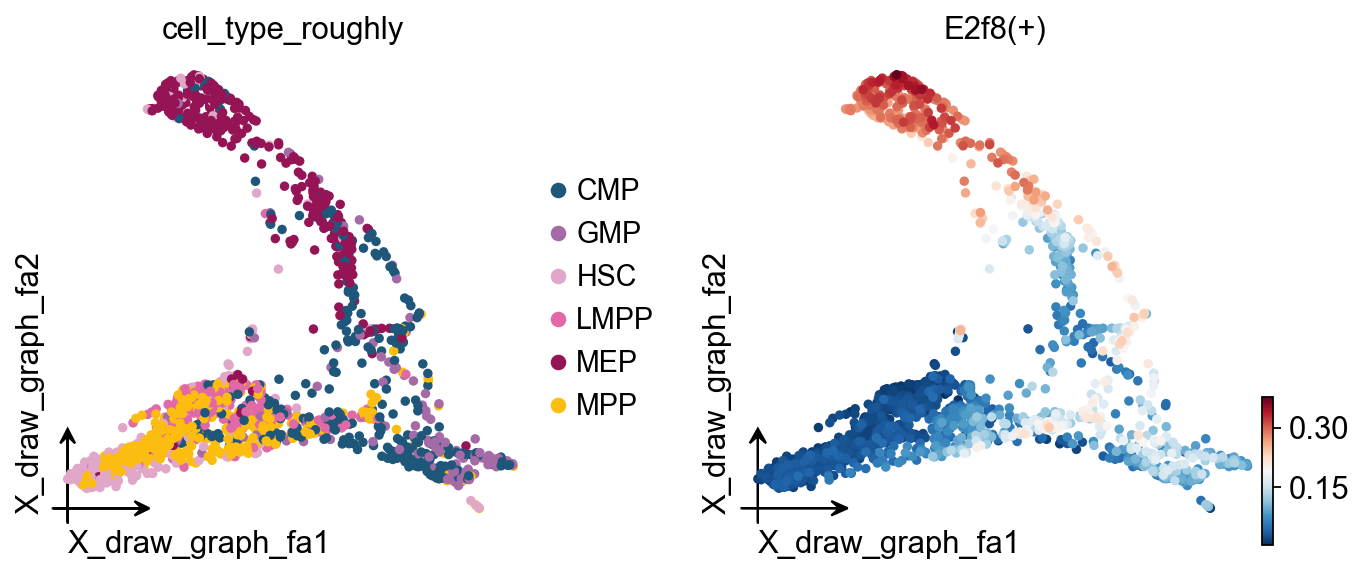

In [10]:
# Visualize regulon activity on the cell embedding
ov.pl.embedding(
    regulon_ad,
    basis='X_draw_graph_fa',              # Use the graph-based embedding
    color=['cell_type_roughly',           # Show cell types
           'E2f8(+)'],                    # Show E2f8 regulon activity
    ncols=2,                              # Show two plots side by side
)

In [11]:
# Save the SCENIC object (contains all analysis results)
ov.utils.save(scenic_obj, 'results/scenic_obj.pkl')

# Save the regulon activity AnnData object
regulon_ad.write('results/scenic_regulon_ad.h5ad')

💾 Save Operation:
   Target path: results/scenic_obj.pkl
   Object type: SCENIC
   Using: pickle
   Pickle failed, switching to: cloudpickle
   ✅ Successfully saved using cloudpickle!
────────────────────────────────────────────────────────────


In [12]:
# Load the saved SCENIC results (for demonstration)
print("Loading saved SCENIC results...")

# Load the SCENIC object
scenic_obj = ov.utils.load('results/scenic_obj.pkl')

# Load the regulon activity AnnData object
regulon_ad = ov.read('results/scenic_regulon_ad.h5ad')

Loading saved SCENIC results...
📂 Load Operation:
   Source path: results/scenic_obj.pkl
   Using: pickle
   ✅ Successfully loaded!
   Loaded object type: SCENIC
────────────────────────────────────────────────────────────


## 5. Regulon Specificity Analysis

### Understanding Regulon Specificity Scores (RSS)

**RSS** measures how specific a regulon is to particular cell types:

- **Range**: Usually 0-1; values closer to 1 indicate stronger cell-type specificity.
- **Calculation**: Based on Jensen-Shannon divergence comparing regulon activity distributions across cell types.
- **Interpretation**:
  - **High RSS** (for example, >0.8): The regulon is strongly biased toward one or a few cell types.
  - **Medium RSS** (for example, 0.5-0.8): The regulon shows moderate cell-type preference.
  - **Low RSS** (for example, <0.5): The regulon may be broadly active across multiple cell types.


In [13]:
# Import modules required for RSS analysis
from omicverse.external.pyscenic.rss import regulon_specificity_scores
from omicverse.external.pyscenic.plotting import plot_rss
from adjustText import adjust_text

### Calculate RSS Values

Here we calculate RSS from the AUCell activity matrix and cell type annotations to identify representative regulatory programs for each cell type.


In [14]:
# Calculate Regulon Specificity Scores (RSS)
print("Calculating regulon specificity scores across cell types...")

# Calculate RSS using the AUCell matrix and cell type annotations
rss = regulon_specificity_scores(
    scenic_obj.auc_mtx,                    # AUCell activity matrix
    scenic_obj.adata.obs['cell_type_roughly']  # Cell type annotations
)

print(f"RSS matrix shape: {rss.shape}")
print(f"Cell types: {list(rss.index)}")
print(f"Number of regulons: {len(rss.columns)}")
print(f"RSS value range: {rss.min().min():.3f} - {rss.max().max():.3f}")

# Display the RSS matrix
print("\nRSS matrix (first 5 regulons):")
rss.head()

Calculating regulon specificity scores across cell types...
RSS matrix shape: (6, 76)
Cell types: ['MPP', 'HSC', 'LMPP', 'GMP', 'CMP', 'MEP']
Number of regulons: 76
RSS value range: 0.167 - 0.586

RSS matrix (first 5 regulons):


      Bhlhe40(+)   Cbfb(+)  Cpeb1(+)   E2f8(+)   Egr1(+)  Epas1(+)   Ets1(+)  \
MPP     0.181419  0.389667  0.210569  0.267546  0.376360  0.274845  0.393478   
HSC     0.183471  0.295874  0.212013  0.249592  0.372101  0.412860  0.327234   
LMPP    0.190182  0.350515  0.202666  0.246496  0.314728  0.217754  0.380285   
GMP     0.175766  0.266569  0.172338  0.250105  0.230656  0.198548  0.243789   
CMP     0.171106  0.357283  0.203163  0.335582  0.326246  0.222702  0.326706   

      Figla(+)    Fos(+)  Foxi1(+)  ...   Tcf7(+)  Zfp128(+)  Zfp143(+)  \
MPP   0.251658  0.385452  0.220387  ...  0.167445   0.239380   0.258118   
HSC   0.276876  0.341523  0.246997  ...  0.178195   0.244289   0.249522   
LMPP  0.240545  0.348469  0.209479  ...  0.171876   0.222789   0.238354   
GMP   0.264317  0.232999  0.173508  ...  0.167445   0.211139   0.235405   
CMP   0.258374  0.335487  0.195050  ...  0.167445   0.279395   0.306557   

      Zfp202(+)  Zfp366(+)  Zfp454(+)  Zfp467(+)  Zfp62(+)  Zfp709(+

### RSS Visualization: Cell-Type-Specific Regulons

The plot below shows the top 5 regulons with the highest RSS for each cell type. It helps identify:

- **Key regulators**: The most cell-type-specific TF regulons for each cell type.
- **Regulatory signatures**: TF activity programs associated with different cell types.
- **Developmental patterns**: Changes in regulon specificity during hematopoietic differentiation.

**How to read the plot**:
- **Y-axis**: RSS score; higher means more specific.
- **Labels**: Top regulons for each cell type.
- **Colors**: Different cell types.
- **Patterns**: Note which TFs are specifically active in certain cell types and which TFs are broadly active across multiple cell types.


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


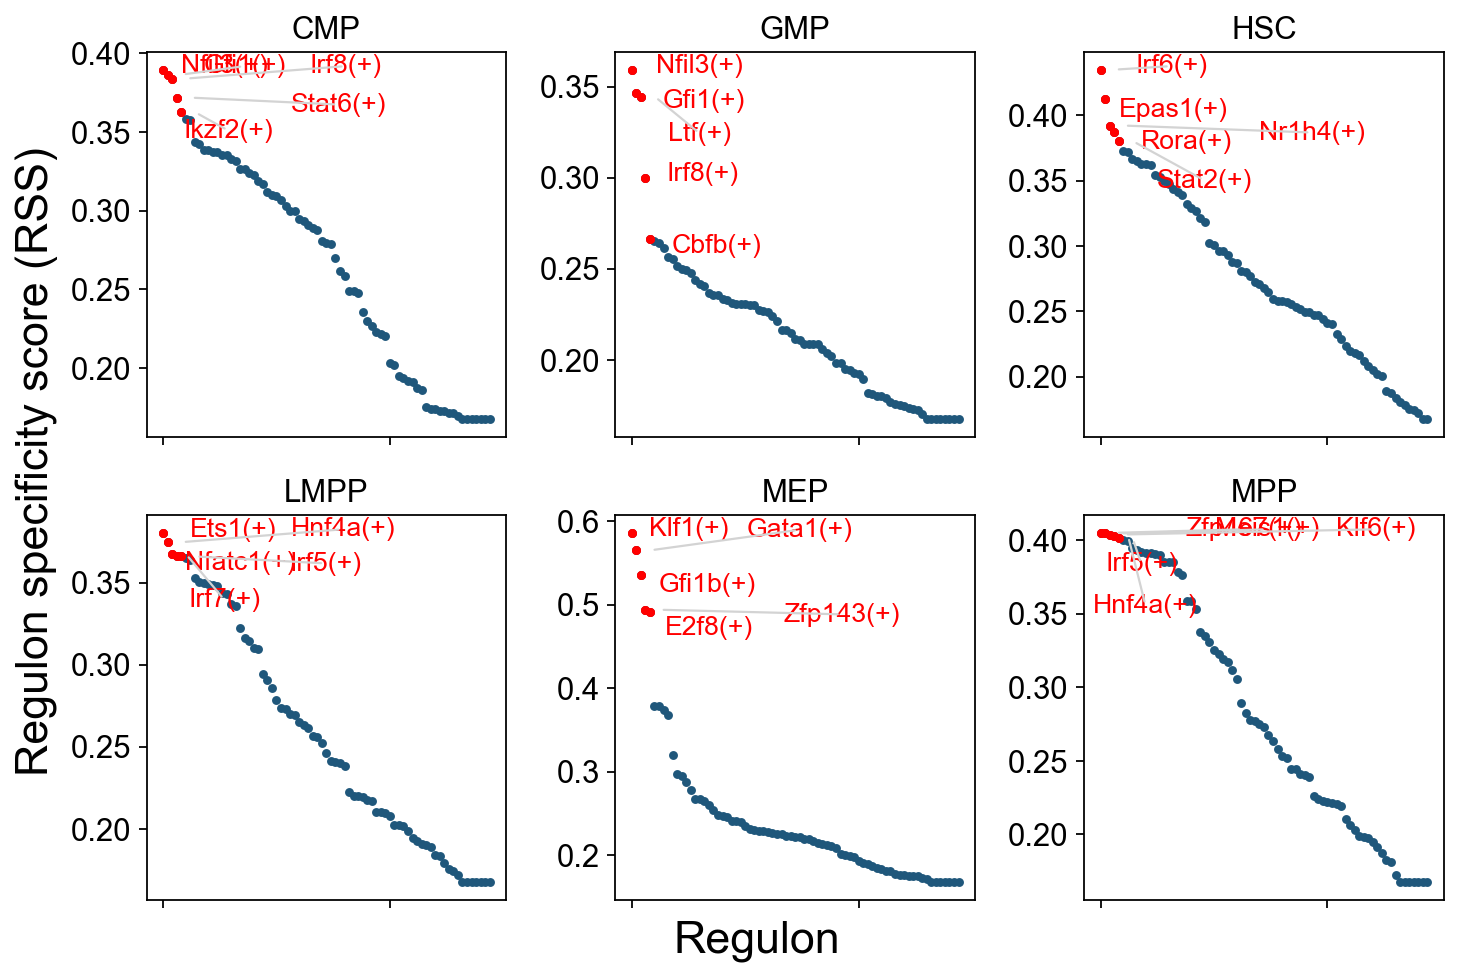

In [15]:
cats = sorted(list(set(adata.obs['cell_type_roughly'])))

fig = ov.plt.figure(figsize=(9, 6))
for c,num in zip(cats, range(1,len(cats)+1)):
    x=rss.T[c]
    ax = fig.add_subplot(2,3,num)
    plot_rss(rss, c, top_n=5, max_n=None, ax=ax)
    ax.set_ylim( x.min()-(x.max()-x.min())*0.05 , x.max()+(x.max()-x.min())*0.05 )
    for t in ax.texts:
        t.set_fontsize(12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    adjust_text(ax.texts, autoalign='xy', ha='right', 
                va='bottom', arrowprops=dict(arrowstyle='-',color='lightgrey'), precision=0.001 )
 
fig.text(0.5, 0.0, 'Regulon', ha='center', va='center', size='x-large')
fig.text(0.00, 0.5, 'Regulon specificity score (RSS)', ha='center', va='center', rotation='vertical', size='x-large')
ov.plt.tight_layout()

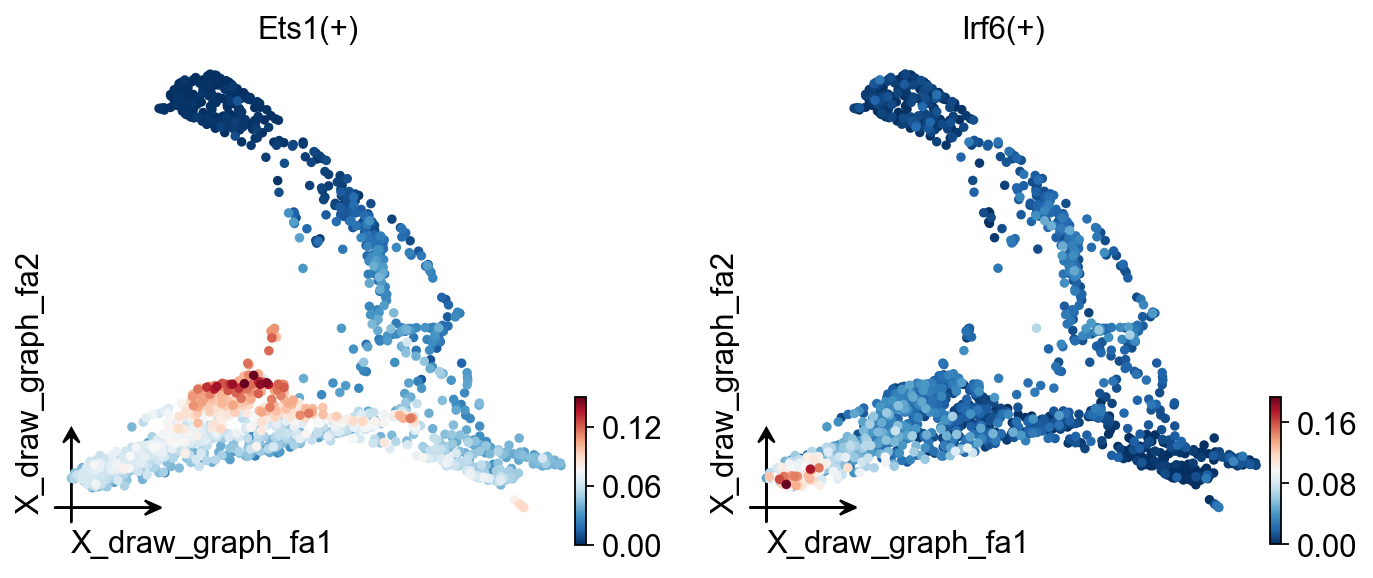

In [16]:
ov.pl.embedding(
    regulon_ad,
    basis='X_draw_graph_fa',
    color=['Ets1(+)','Irf6(+)']
)

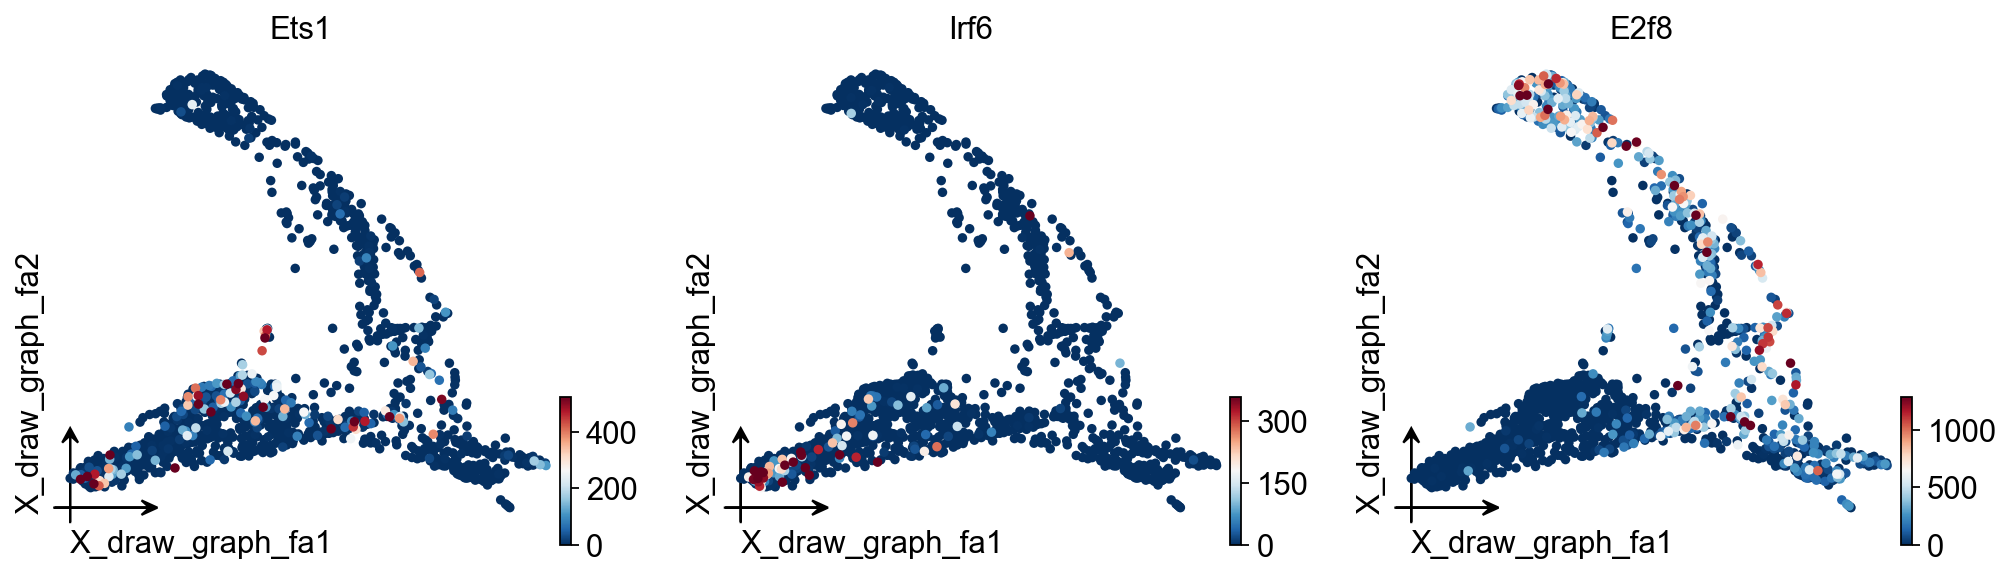

In [17]:
ov.pl.embedding(
    adata,
    basis='X_draw_graph_fa',
    color=['Ets1','Irf6','E2f8'],
    vmax='p99.2'
)

In [18]:
regulon_ad

AnnData object with n_obs × n_vars = 1645 × 76
    obs: 'E_pseudotime', 'GM_pseudotime', 'L_pseudotime', 'label_info', 'n_genes', 'leiden', 'cell_type_roughly', 'cell_type_finely'
    uns: 'cell_type_roughly_colors', 'cell_type_roughly_colors_rgba'
    obsm: 'X_draw_graph_fa', 'X_pca'

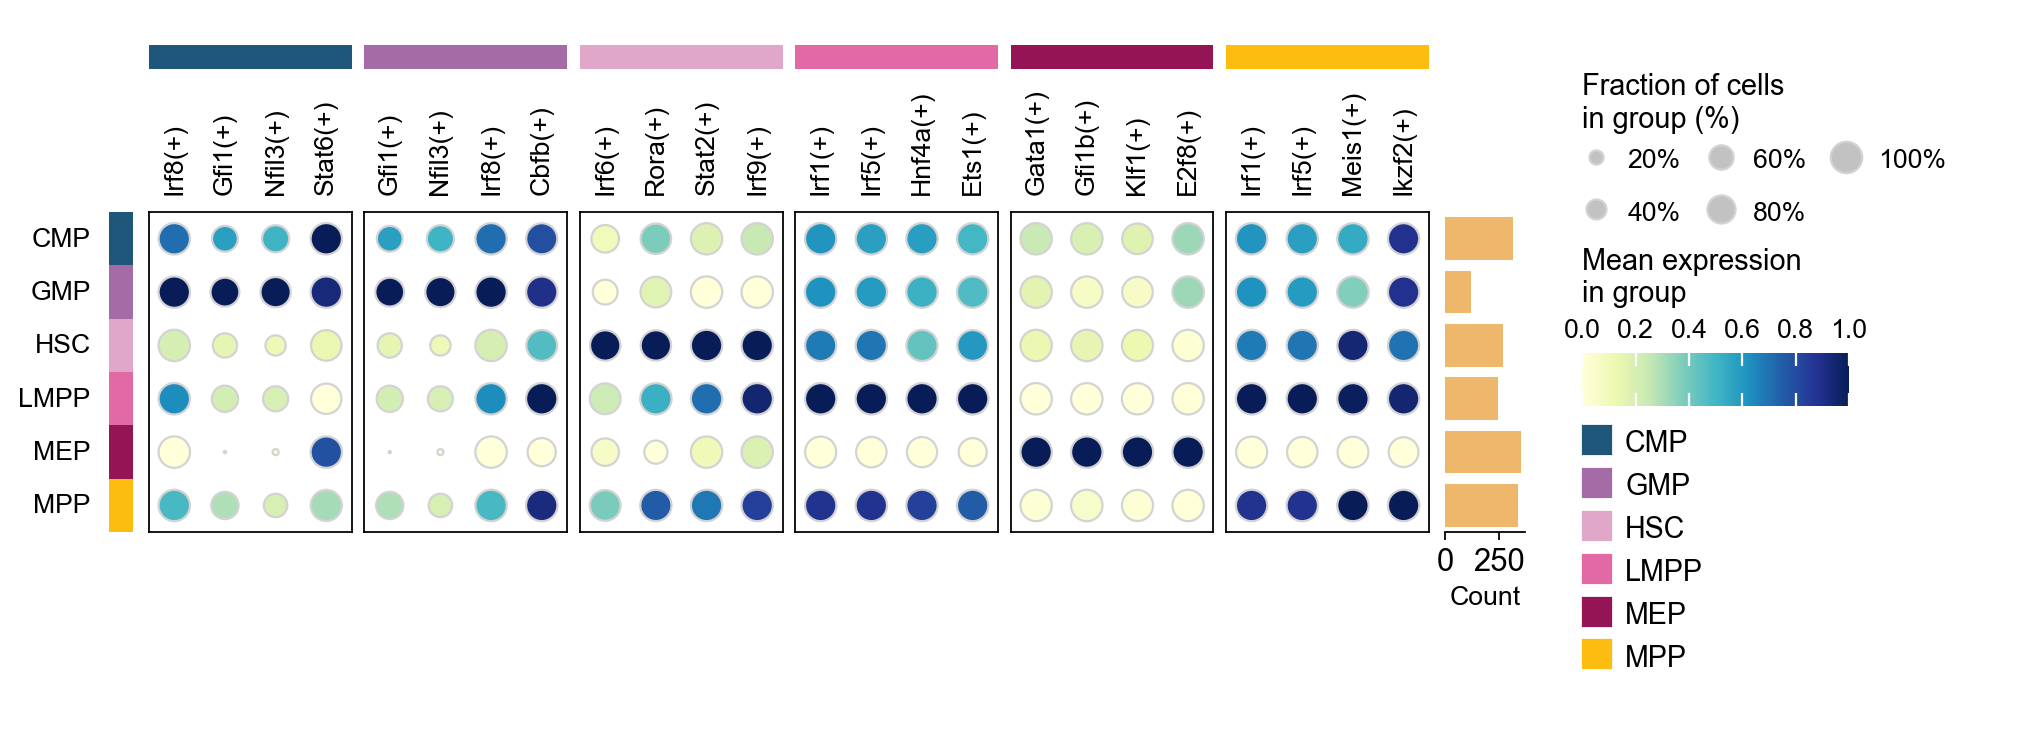

In [19]:
sc.tl.dendrogram(regulon_ad,'cell_type_roughly',use_rep='X_pca')
sc.tl.rank_genes_groups(regulon_ad, 'cell_type_roughly', use_rep='X_pca',
                        method='t-test',use_raw=False,key_added='cell_type_roughly_ttest')
ov.pl.rank_genes_groups_dotplot(regulon_ad,groupby='cell_type_roughly',
                                cmap='YlGnBu',key='cell_type_roughly_ttest',
                                standard_scale='var',n_genes=4,dendrogram=False)

**finished identifying marker genes by COSG**


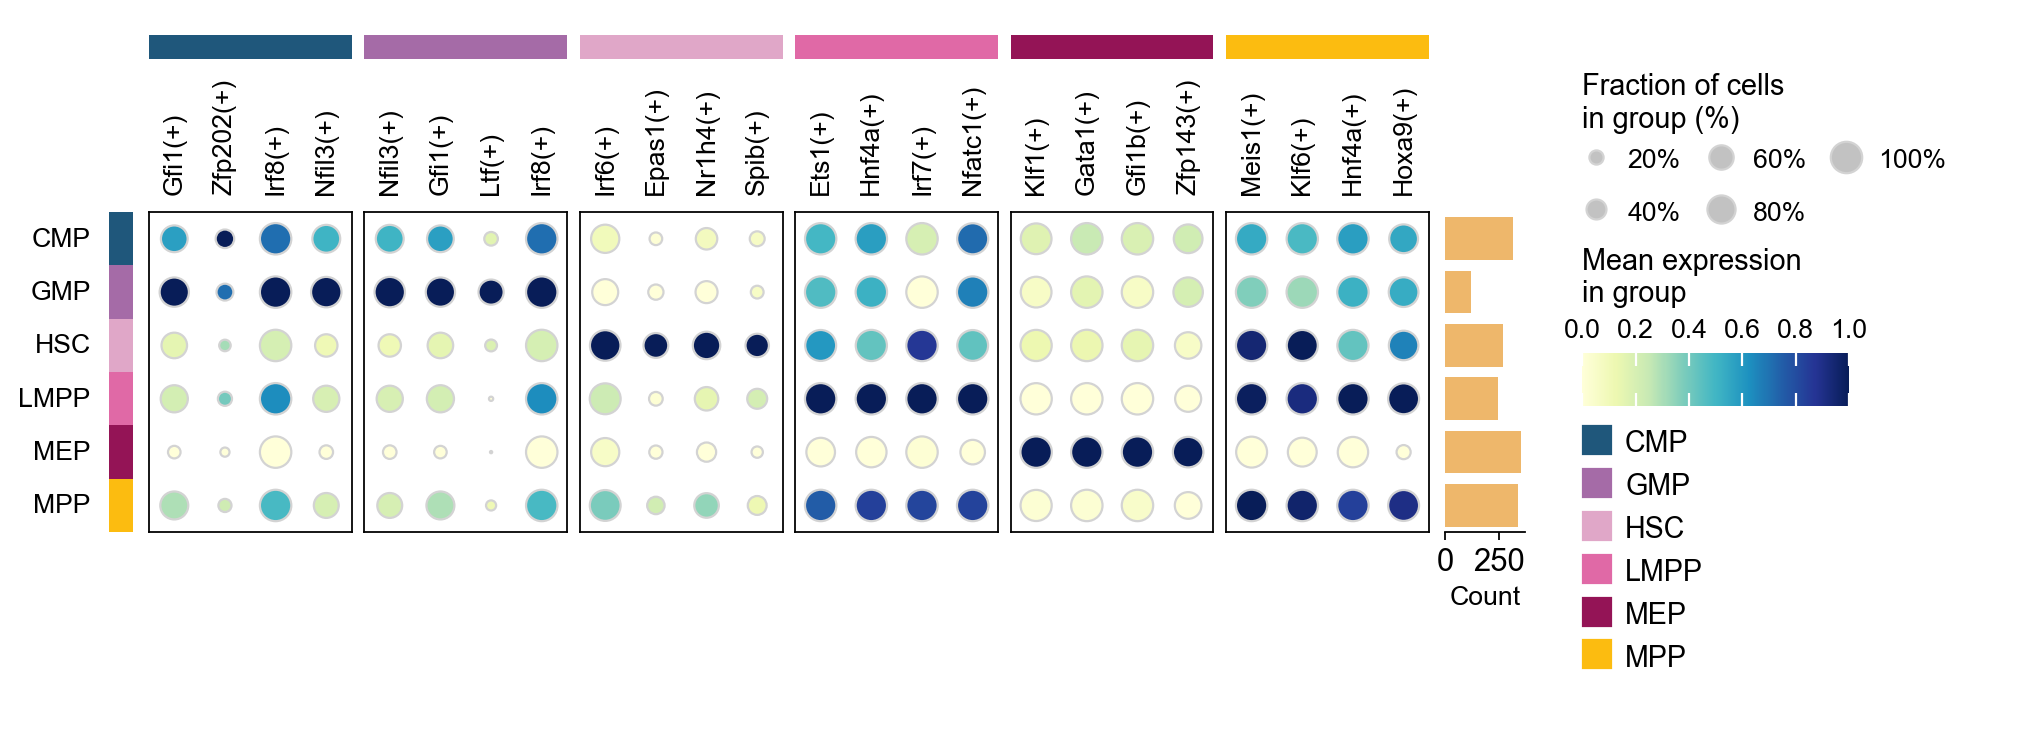

In [20]:
sc.tl.rank_genes_groups(regulon_ad, groupby='cell_type_roughly', 
                        method='t-test',use_rep='scaled|original|X_pca',)
ov.single.cosg(regulon_ad, key_added='cell_type_roughly_cosg', groupby='cell_type_roughly')
ov.pl.rank_genes_groups_dotplot(regulon_ad,groupby='cell_type_roughly',
                                cmap='YlGnBu',key='cell_type_roughly_cosg',
                                standard_scale='var',n_genes=4,dendrogram=False)

### Generate a Binary Regulon Activity Matrix


In [21]:
from omicverse.external.pyscenic.binarization import binarize
binary_mtx, auc_thresholds = binarize(
    scenic_obj.auc_mtx, num_workers=8
)
binary_mtx.head()

Regulon     Bhlhe40(+)  Cbfb(+)  Cpeb1(+)  E2f8(+)  Egr1(+)  Epas1(+)  \
HSPC_025             0        1         0        0        1         1   
LT-HSC_001           0        1         0        0        0         1   
HSPC_008             0        1         0        0        1         0   
HSPC_020             0        1         0        0        1         0   
HSPC_026             0        1         0        0        0         0   

Regulon     Ets1(+)  Figla(+)  Fos(+)  Foxi1(+)  ...  Tcf7(+)  Zfp128(+)  \
HSPC_025          1         0       1         0  ...        0          0   
LT-HSC_001        1         0       0         0  ...        0          1   
HSPC_008          1         0       1         0  ...        0          0   
HSPC_020          1         0       0         1  ...        0          0   
HSPC_026          1         0       0         1  ...        0          0   

Regulon     Zfp143(+)  Zfp202(+)  Zfp366(+)  Zfp454(+)  Zfp467(+)  Zfp62(+)  \
HSPC_025            0    

### Show AUC Distributions for Selected Regulons


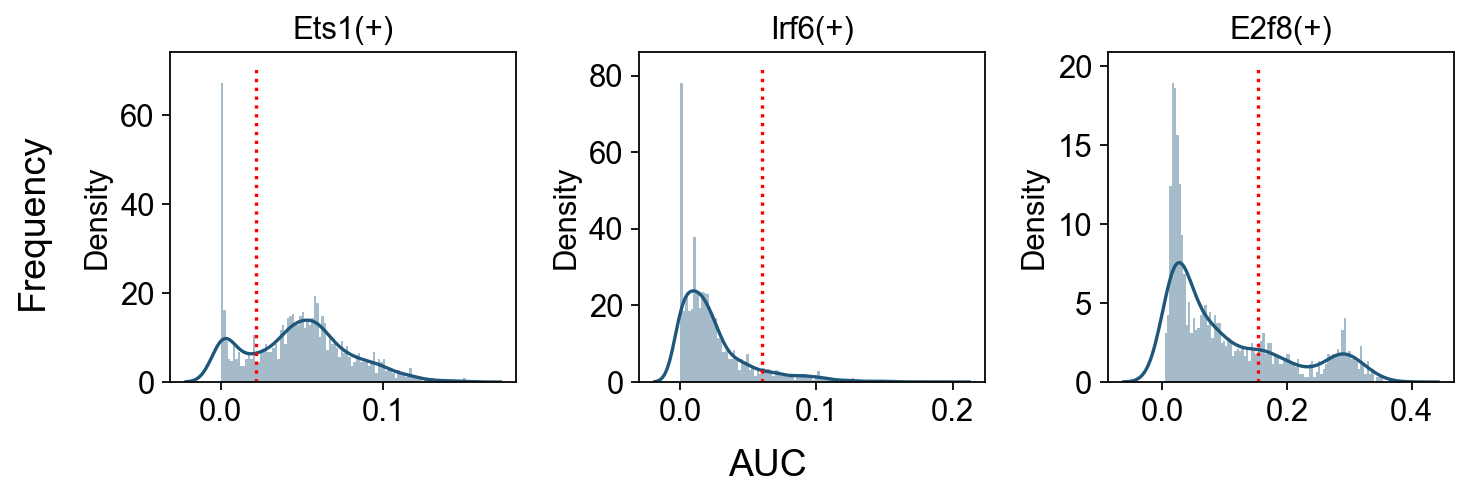

In [22]:
# Select regulons:
import seaborn as sns
r = [ 'Ets1(+)','Irf6(+)','E2f8(+)' ]

fig, axs = ov.plt.subplots(1, 3, figsize=(9, 3), dpi=80, sharey=False)
for i,ax in enumerate(axs):
    sns.distplot(scenic_obj.auc_mtx[ r[i] ], ax=ax, norm_hist=True, bins=100)
    ax.plot( [ auc_thresholds[ r[i] ] ]*2, ax.get_ylim(), 'r:')
    ax.title.set_text( r[i] )
    ax.set_xlabel('')
    
fig.text(-0.01, 0.5, 'Frequency', ha='center', va='center', rotation='vertical', size='large')
fig.text(0.5, -0.01, 'AUC', ha='center', va='center', rotation='horizontal', size='large')

fig.tight_layout()

## GRN Exploration and Visualization


In [23]:
tf = 'Irf6'
tf_mods = [ x for x in scenic_obj.modules if x.transcription_factor==tf ]

for i,mod in enumerate( tf_mods ):
    print( f'{tf} module {str(i)}: {len(mod.genes)} genes' )

tf_regulons = [ x for x in scenic_obj.regulons if x.transcription_factor==tf ]
for i,mod in enumerate( tf_regulons ):
    print( f'{tf} regulon: {len(mod.genes)} genes' )

Irf6 module 0: 456 genes
Irf6 module 1: 226 genes
Irf6 module 2: 51 genes
Irf6 module 3: 66 genes
Irf6 regulon: 62 genes


In [24]:
tf_list=[i.replace('(+)','') for i in regulon_ad.var_names.tolist()]
gene_list=[]

# TF-Target dict
tf_gene_dict={}
for tf in tf_list:
    tf_regulons = [ x for x in scenic_obj.regulons if x.transcription_factor==tf ]
    for i,mod in enumerate( tf_regulons ):
        gene_list+=mod.genes
        tf_gene_dict[tf]=list(mod.genes)

gene_list+=tf_list
gene_list=list(set(gene_list))

In [25]:
adata_T=adata[:,gene_list].copy().T
sc.tl.pca(adata_T)
sc.pp.neighbors(adata_T,use_rep='X_pca')
sc.tl.umap(adata_T)

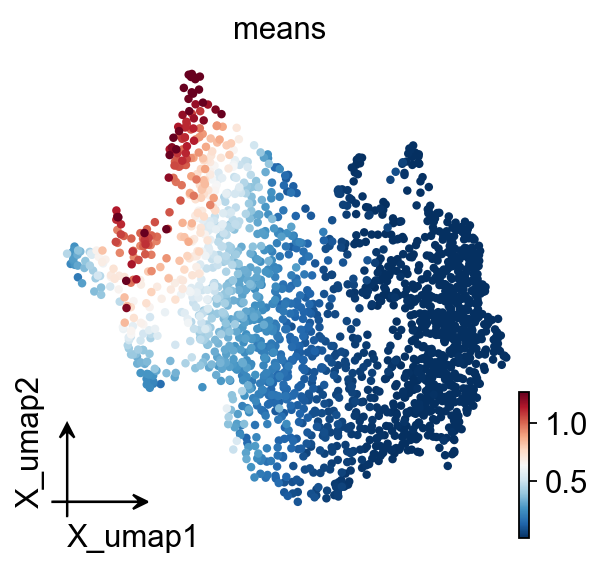

In [26]:
ov.pl.embedding(
    adata_T,
    basis='X_umap',
    color=['means'],
    vmax='p99.2'
)

In [27]:
embedding_df=ov.pd.DataFrame(
    adata_T.obsm['X_pca'],
    index=adata_T.obs.index
)
embedding_df.head()

                 0           1           2           3          4   \
Mki67    413.020935  507.103546  189.998505 -125.715866 -54.114349   
Nxpe2     81.864555  430.134827  -29.737476 -171.069229 -29.956656   
Efcc1    -64.621864  -58.122742  -30.066536  -26.164042  -4.405851   
Zfp521   -89.460197  -38.026447  -22.520176    1.900368 -13.516800   
Laptm4b   37.708977 -127.082298  -57.854221  -78.198860 -22.131437   

                 5           6          7          8          9   ...  \
Mki67    241.781494  314.045013  -3.373584  -9.383018 -38.049488  ...   
Nxpe2    -80.710686   34.901363 -20.325682 -18.290096  85.208061  ...   
Efcc1      0.209314   -5.303875  -9.185871 -18.768551  11.752351  ...   
Zfp521    -4.603009   -0.892507 -15.595396  -4.634521  -6.174720  ...   
Laptm4b  -11.139277  -12.517421 -42.676773 -19.097021 -29.525038  ...   

                40         41         42         43         44         45  \
Mki67     0.666770 -15.700621   2.257979  44.322483   5.286233 

In [28]:
# Build the network
G, pos, correlation_matrix = ov.single.build_correlation_network_umap_layout(
    embedding_df, 
    correlation_threshold=0.95,  
    umap_neighbors=15
)

Network built successfully:
  Node number: 2054
  Edge number: 415574
  Correlation threshold: 0.95


In [29]:
G, tf_genes = ov.single.add_tf_regulation(G, tf_gene_dict)

Add regulation relationship:
  TF gene number: 76
  Regulation edge number: 5596


In [30]:
temporal_df=adata_T.obs.copy()
temporal_df['peak_temporal_center']=temporal_df['means']

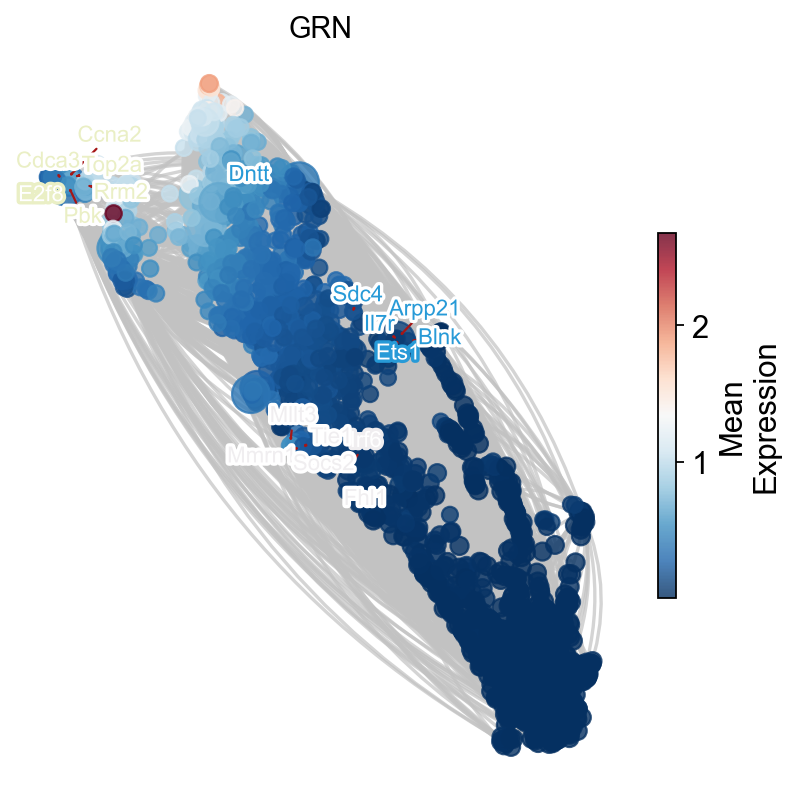

In [31]:
ax=ov.single.plot_grn(
    G,pos, ['Ets1','Irf6','E2f8'],
    temporal_df,tf_gene_dict,
    figsize=(6,6),
    top_tf_target_num=5,
    title='GRN'
)